In [1]:
import pandas as pd
raw = pd.read_csv('http://hilpisch.com/pyalgo_eikon_eod_data.csv',
                            index_col=0, parse_dates=True).dropna()

In [2]:
raw.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 2516 entries, 2010-01-04 to 2019-12-31
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AAPL.O  2516 non-null   float64
 1   MSFT.O  2516 non-null   float64
 2   INTC.O  2516 non-null   float64
 3   AMZN.O  2516 non-null   float64
 4   GS.N    2516 non-null   float64
 5   SPY     2516 non-null   float64
 6   .SPX    2516 non-null   float64
 7   .VIX    2516 non-null   float64
 8   EUR=    2516 non-null   float64
 9   XAU=    2516 non-null   float64
 10  GDX     2516 non-null   float64
 11  GLD     2516 non-null   float64
dtypes: float64(12)
memory usage: 255.5 KB


In [3]:
data=pd.DataFrame(raw['EUR='])

In [4]:
data[:5]

,EUR=
Date,
2010-01-04,1.4411
2010-01-05,1.4368
2010-01-06,1.4412
2010-01-07,1.4318
2010-01-08,1.4412


In [5]:
data.rename(columns={'EUR=':'price'}, inplace=True)

In [6]:
data.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 2516 entries, 2010-01-04 to 2019-12-31
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   price   2516 non-null   float64
dtypes: float64(1)
memory usage: 39.3 KB


In [7]:
data[::5]

,price
Date,
2010-01-04,1.4411
2010-01-11,1.4513
2010-01-19,1.4298
2010-01-26,1.4073
2010-02-02,1.3961
...,...
2019-12-02,1.1077
2019-12-09,1.1062
2019-12-16,1.1142


In [8]:
data['SMA1'] = data['price'].rolling(42).mean()

In [9]:
data['SMA2'] = data['price'].rolling(252).mean()

In [10]:
data.tail()

,price,SMA1,SMA2
Date,,,
2019-12-24,1.1087,1.107698,1.119630
2019-12-26,1.1096,1.107740,1.119529
2019-12-27,1.1175,1.107924,1.119428
2019-12-30,1.1197,1.108131,1.119333
2019-12-31,1.1210,1.108279,1.119231


In [11]:
%matplotlib inline
from pylab import mpl, plt
plt.style.use('seaborn-v0_8')
mpl.rcParams['savefig.dpi']=300
mpl.rcParams['font.family']='serif'

<Axes: title={'center': 'EUR/USD | 42 & 252 days SMAs'}, xlabel='Date'>

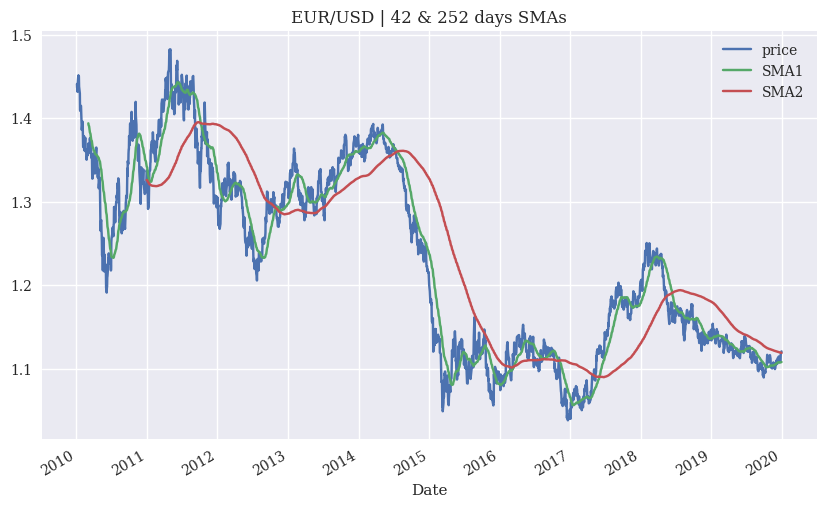

In [12]:
data.plot(title='EUR/USD | 42 & 252 days SMAs', figsize=(10, 6))

In [13]:
import numpy as np
data['position'] = np.where(data['SMA1'] > data['SMA2'], 1, -1)

In [14]:
data.dropna(inplace=True)

<Axes: title={'center': 'MARKET POSITIONING'}, xlabel='Date'>

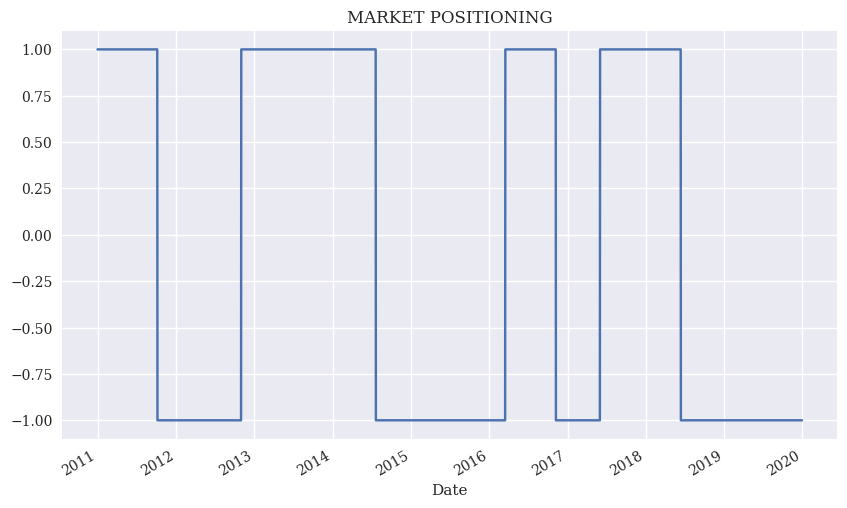

In [15]:
data['position'].plot(ylim=[-1.1, 1.1], title='MARKET POSITIONING', figsize=(10, 6))

In [16]:
data['returns'] = np.log(data['price'] / data['price'].shift(1))

<Axes: >

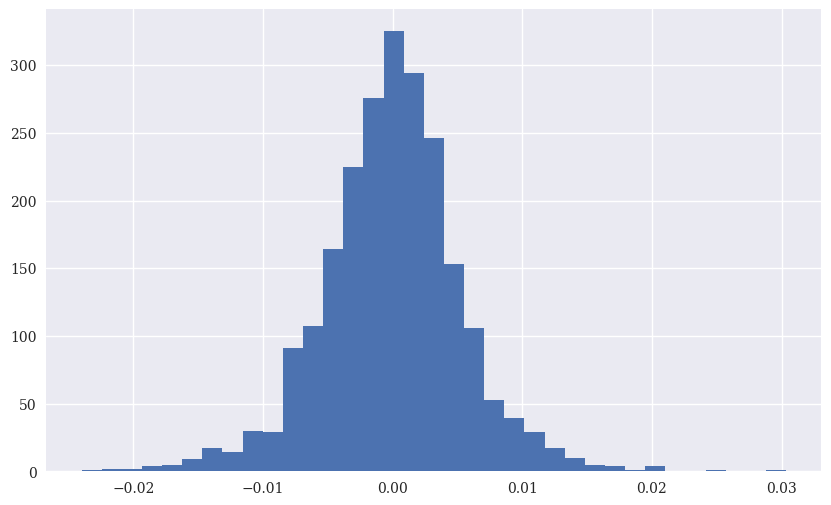

In [17]:
data['returns'].hist(bins=35, figsize=(10, 6))

In [18]:
data['strategy'] = data['position'].shift(1) * data['returns']

In [19]:
data[['returns', 'strategy']].sum()

returns    -0.176731
strategy    0.253121
dtype: float64

In [20]:
data[['returns', 'strategy']].sum().apply(np.exp)

returns     0.838006
strategy    1.288039
dtype: float64

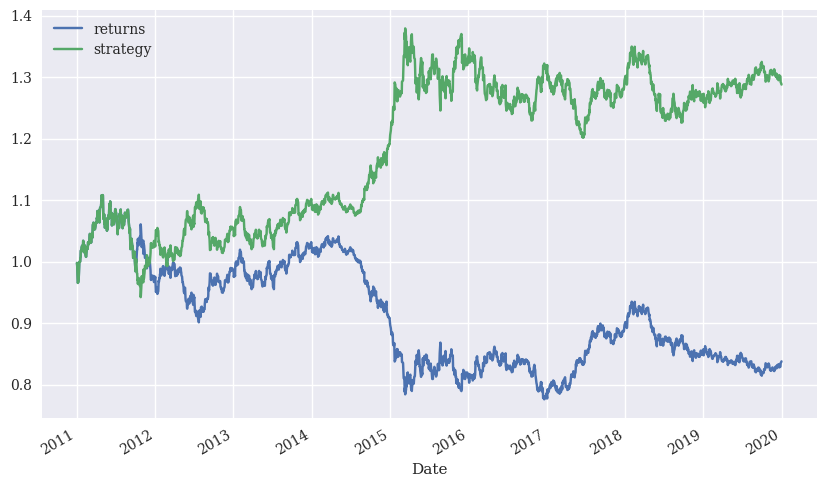

In [21]:
data[['returns', 'strategy']].cumsum().apply(np.exp).plot(figsize=(10, 6));

In [22]:
data[['returns', 'strategy']].mean() * 252

returns    -0.019671
strategy    0.028174
dtype: float64

In [23]:
np.exp(data[['returns', 'strategy']].mean() * 252) - 1

returns    -0.019479
strategy    0.028575
dtype: float64

In [24]:
data[['returns', 'strategy']].std() * 252 ** 0.5

returns     0.085414
strategy    0.085405
dtype: float64

In [25]:
(data[['returns', 'strategy']].apply(np.exp) - 1).std() * 252 ** 0.5

returns     0.085405
strategy    0.085373
dtype: float64

In [26]:
data['cumret'] = data['strategy'].cumsum().apply(np.exp)

In [27]:
data['cummax'] = data['cumret'].cummax()

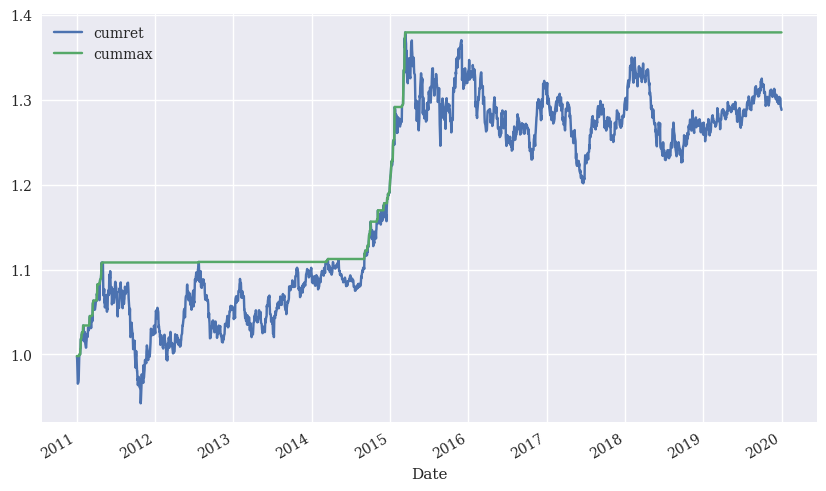

In [28]:
data[['cumret', 'cummax']].dropna().plot(figsize=(10, 6));

In [29]:
drawdown = data['cummax'] - data['cumret']

In [30]:
drawdown.max()

np.float64(0.17779367070195895)

In [31]:
temp = drawdown[drawdown == 0]

In [32]:
periods=(temp.index[1:].to_pydatetime() - temp.index[:-1].to_pydatetime())

In [33]:
periods[12:15]

array([datetime.timedelta(days=1), datetime.timedelta(days=1),
       datetime.timedelta(days=10)], dtype=object)

In [34]:
periods.max()

datetime.timedelta(days=596)

In [35]:
import SMAVectorBacktester as SMA

In [36]:
smabt = SMA.SMAVectorBacktester('EUR=', 42, 252, '2010-1-1', '2019-12-31')

In [37]:
smabt.run_strategy()

(np.float64(1.29), np.float64(0.45))

In [42]:
%time smabt.optimize_parameters((30, 50, 2), (200, 300, 2))

CPU times: user 943 ms, sys: 10.7 ms, total: 954 ms
Wall time: 942 ms


(array([ 48., 238.]), np.float64(1.5))

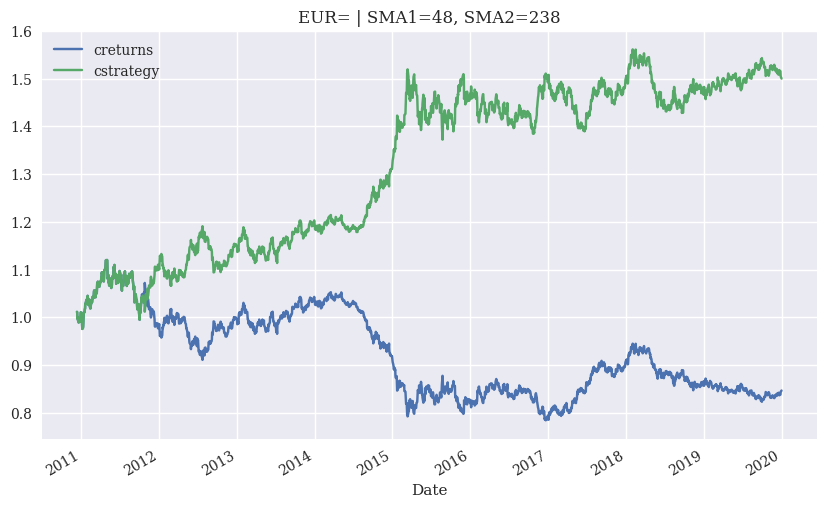

In [43]:
smabt.plot_results()